In [1]:
%pip install psycopg2 polars connectorx

Note: you may need to restart the kernel to use updated packages.


In [72]:
import os
import pandas as pd
import polars as pl
from dotenv import load_dotenv, find_dotenv
import lightgbm as lgb
from sqlalchemy import create_engine
import psycopg2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from scipy.stats import spearmanr

import matplotlib.pyplot as plt

In [3]:
def db_connection_string():
    load_dotenv(find_dotenv())

    host = 'localhost'
    port = 5433
    db = os.getenv('POSTGRES_DB')
    user = os.getenv('POSTGRES_USER')
    password = os.getenv('POSTGRES_PASSWORD')
    
    return f'postgresql://{user}:{password}@{host}:{port}/{db}'

In [6]:
def query_database(query: str):
    conn_str = db_connection_string()
    
    df = pl.read_database_uri(query=query, uri=conn_str)

    decimal_cols = [c for c, dtype in df.schema.items() if dtype == pl.Decimal]
    df = df.with_columns([pl.col(c).cast(pl.Float64) for c in decimal_cols])
    df_pandas = df.to_pandas()

    return df_pandas

In [11]:
query = """
    SELECT fix.season, feat.*
    FROM dev_ml.all_features feat
    JOIN dev_serving.dim_fixture fix
    ON feat.fixture_key = fix.fixture_key
"""

df_features = query_database(query)
df_features

,season,player_game_key,fixture_key,fpl_position,team_id,at_home,games_prior,appearance_rate,starting_rate,clean_sheet_rate,...,prev_season_influence_per_90,prev_season_creativity_per_90,prev_season_threat_per_90,prev_season_ict_index_per_90,prev_season_expected_goals_per_90,prev_season_expected_assists_per_90,prev_season_expected_goal_involvements_per_90,prev_season_expected_goal_chain_per_90,prev_season_expected_goal_buildup_per_90,league_avg_bps_this_season
0,2020,2020_126_275,2020_126,DEF,45,False,12,0.083333,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743
1,2020,2020_126_276,2020_126,DEF,45,False,12,1.000000,1.000000,0.166667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743
2,2020,2020_126_277,2020_126,DEF,45,False,12,0.250000,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743
3,2020,2020_126_278,2020_126,FWD,45,False,12,1.000000,1.000000,0.083333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743
4,2020,2020_126_279,2020_126,FWD,45,False,12,0.416667,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255396,2020,2020_12_62,2020_12,DEF,91,False,1,0.000000,NaN,NaN,...,24.381418,12.711491,2.860636,3.990220,0.008887,0.044350,0.053237,0.334668,0.318294,7.098446
255397,2020,2020_126_205,2020_126,DEF,11,True,12,0.583333,0.857143,0.000000,...,19.171745,12.191136,2.991690,3.427978,0.008702,0.048074,0.056776,0.611014,0.601696,6.668743
255398,2020,2020_126_272,2020_126,DEF,45,False,12,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743
255399,2020,2020_126_273,2020_126,DEF,45,False,12,1.000000,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743


In [12]:
query = """
    SELECT 
        player_game_key,
        total_points_recalculated
    FROM
        dev_serving.fact_player_game
"""

df_target = query_database(query)
df_target

,player_game_key,total_points_recalculated
0,2017_220_350,2.0
1,2018_19_389,2.0
2,2019_266_170,0.0
3,2026_352_44,1.0
4,2026_316_387,5.0
...,...,...
255396,2019_118_282,1.0
255397,2025_301_731,1.0
255398,2025_272_137,0.0
255399,2022_220_429,9.0


In [13]:
df_all = pd.merge(df_features, df_target, on='player_game_key', how='inner')
df_all

,season,player_game_key,fixture_key,fpl_position,team_id,at_home,games_prior,appearance_rate,starting_rate,clean_sheet_rate,...,prev_season_creativity_per_90,prev_season_threat_per_90,prev_season_ict_index_per_90,prev_season_expected_goals_per_90,prev_season_expected_assists_per_90,prev_season_expected_goal_involvements_per_90,prev_season_expected_goal_chain_per_90,prev_season_expected_goal_buildup_per_90,league_avg_bps_this_season,total_points_recalculated
0,2020,2020_126_275,2020_126,DEF,45,False,12,0.083333,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743,5.0
1,2020,2020_126_276,2020_126,DEF,45,False,12,1.000000,1.000000,0.166667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743,0.0
2,2020,2020_126_277,2020_126,DEF,45,False,12,0.250000,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743,0.0
3,2020,2020_126_278,2020_126,FWD,45,False,12,1.000000,1.000000,0.083333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743,5.0
4,2020,2020_126_279,2020_126,FWD,45,False,12,0.416667,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255396,2020,2020_12_62,2020_12,DEF,91,False,1,0.000000,NaN,NaN,...,12.711491,2.860636,3.990220,0.008887,0.044350,0.053237,0.334668,0.318294,7.098446,0.0
255397,2020,2020_126_205,2020_126,DEF,11,True,12,0.583333,0.857143,0.000000,...,12.191136,2.991690,3.427978,0.008702,0.048074,0.056776,0.611014,0.601696,6.668743,0.0
255398,2020,2020_126_272,2020_126,DEF,45,False,12,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743,0.0
255399,2020,2020_126_273,2020_126,DEF,45,False,12,1.000000,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.668743,6.0


In [41]:
def preprocess_data(df, fit_categories=None, fit=False):
    # Drop identifier and descriptive columns
    id_cols = [col for col in df.columns if col.endswith('_id') or col.endswith('_key') or col == 'season']
    df = df.drop(columns=id_cols)

    # Convert boolean columns to integer
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()                
    for col in bool_cols:
        df[col] = df[col].astype('int')

    # Convert object columns to category type
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    categories = {} if fit else fit_categories
    
    for col in cat_cols:
        if fit:
            df[col] = df[col].astype('category')
            categories[col] = df[col].cat.categories
        else:
            df[col] = pd.Categorical(df[col], categories=categories[col])

    # Rename target variable
    df.rename(columns={'total_points_recalculated': 'points'}, inplace=True)

    return df, (categories if fit else None)

In [42]:
train = df_all[df_all['season'] < 2025].copy()
test = df_all[df_all['season'] >= 2025].copy()

In [130]:
df_training, categories = preprocess_data(train, fit=True)
df_test, _ = preprocess_data(test, fit_categories=categories, fit=False)

X_train = df_training.drop(columns=['points'])
y_train = df_training['points']

X_test = df_test.drop(columns=['points'])
y_test = df_test['points']

In [114]:
def train_baseline_model(model, X_train, y_train):    
    model.fit(X_train, y_train)
    
    yhat_train = model.predict(X_train)
    mae = mean_absolute_error(y_train, yhat_train)
    mse = mean_squared_error(y_train, yhat_train)
    spearman = spearmanr(y_train, yhat_train).correlation
    
    print(f'Training MAE: {mae}')
    print(f'Training MSE: {mse}')
    print(f'Training Spearman: {spearman}')
    
    return model, yhat_train

In [49]:
def test_baseline_model(model, X_test, y_test):
    yhat_test = model.predict(X_test)

    mae = mean_absolute_error(y_test, yhat_test)
    mse = mean_squared_error(y_test, yhat_test)
    spearman = spearmanr(y_test, yhat_test).correlation
    
    print(f'Test MAE: {mae}')
    print(f'Test MSE: {mse}')
    print(f'Test Spearman: {spearman}')

    return yhat_test

In [151]:
lgbm = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_l2, yhat_train = train_baseline_model(lgbm, X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.085764 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54094
[LightGBM] [Info] Number of data points in the train set: 196479, number of used features: 247
[LightGBM] [Info] Start training from score 1.325831
Training MAE: 1.0470780034849276
Training MSE: 3.524949845960532
Training Spearman: 0.7088523647716823


In [153]:
yhat_test = test_baseline_model(model_l2, X_test, y_test)

Test MAE: 1.0158521967034024
Test MSE: 3.7860963809890444
Test Spearman: 0.6970377799467207


In [94]:
def get_summary(train_test, X, yhat):
    df = train_test.copy()
    df.loc[X.index, 'yhat'] = yhat

    query = """
        SELECT p.web_name, pg.player_game_key, pg.fixture_key, pg.player_id, pg.total_points_recalculated
        FROM dev_serving.fact_player_game pg
        JOIN dev_serving.dim_player p
        ON pg.player_id = p.player_id
    """

    df_info = query_database(query)

    df_summary = pd.merge(df_info, df[['player_game_key', 'yhat']], on='player_game_key', how='inner')

    return df_summary

In [95]:
get_summary(train, X_train, yhat_train).sort_values(by='yhat', ascending=False).head(50)

,web_name,player_game_key,fixture_key,player_id,total_points_recalculated,yhat
145101,Palmer,2024_325_362,2024_325,244851,26.0,17.860075
27331,Haaland,2024_39_355,2024_39,223094,20.0,15.514081
178929,Sterling,2019_107_270,2019_107,103955,21.0,14.723882
117784,Agüero,2018_264_257,2018_264,37572,21.0,14.426042
15509,Hazard,2019_42_122,2019_42,42786,20.0,14.208942
150933,Palmer,2024_307_362,2024_307,244851,20.0,13.527958
50062,M.Salah,2018_305_234,2018_305,118748,29.0,13.390804
123380,Haaland,2023_88_318,2023_88,223094,23.0,12.924692
10424,Haaland,2023_49_318,2023_49,223094,17.0,12.905122
127973,Kane,2017_374_403,2017_374,78830,17.0,12.890472


In [99]:
df_testing_summary = get_summary(test, X_test, yhat_test)
df_testing_summary.sort_values(by='yhat', ascending=False).head(50)

,web_name,player_game_key,fixture_key,player_id,total_points_recalculated,yhat
52046,Saka,2025_2_17,2025_2,223340,12.0,8.866642
31301,M.Salah,2025_315_328,2025_315,118748,6.0,8.374872
28146,Haaland,2025_17_351,2025_17,223094,17.0,8.185718
6549,Haaland,2025_187_351,2025_187,223094,8.0,8.018245
23065,Haaland,2026_228_430,2026_228,223094,1.0,7.872702
45835,M.Salah,2026_1_381,2026_1,118748,8.0,7.786253
20374,Haaland,2026_334_430,2026_334,223094,7.0,7.714554
7348,Isak,2025_218_401,2025_218,219168,2.0,7.688561
35069,Haaland,2025_298_351,2025_298,223094,0.0,7.629084
340,Haaland,2026_307_430,2026_307,223094,0.0,7.558509


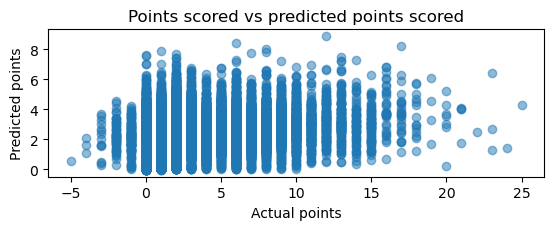

In [81]:
plt.scatter(y_test, yhat_test, alpha=0.5)
plt.xlabel('Actual points')
plt.ylabel('Predicted points')
plt.axis('scaled')
plt.title('Points scored vs predicted points scored')
plt.show()

In [109]:
def get_aggregates(df_summary):
    df_agg = df_summary.groupby(['player_id', 'web_name']).agg(
        pred_std=('yhat', 'std'),
        actual_std=('total_points_recalculated', 'std'),
        pred_mean=('yhat', 'mean'),
        actual_mean=('total_points_recalculated', 'mean'),
        n=('yhat', 'count')
    ).query('n >= 10')

    return df_agg

In [110]:
df_agg = get_aggregates(df_testing_summary)
df_agg.sort_values('actual_mean', ascending=False).head(15)

,,pred_std,actual_std,pred_mean,actual_mean,n
player_id,web_name,,,,,
118748,M.Salah,1.346613,5.288236,5.275802,6.144737,76
223094,Haaland,1.369817,4.889297,5.285536,5.620253,79
141746,B.Fernandes,1.045549,4.976511,4.494723,5.518987,79
446008,Mbeumo,0.869711,4.421298,4.440569,5.126582,79
178186,Bowen,0.894376,3.669696,4.554104,5.000000,76
437730,Semenyo,0.798218,3.938879,4.412233,4.810127,79
222531,Gibbs-White,0.745200,4.177924,3.679809,4.556962,79
178301,Watkins,1.024745,4.168980,3.971930,4.468354,79
244850,Rogers,0.823405,3.771035,3.631028,4.417722,79


### Notes
- Among top players, predicted mean is largely in the correct order compared to actual mean. However test predictions are consistently underpredicted.
- Predicted standard deviation is ~20% of actual values, this may be expected of a noisy target variable such as fpl points.

In [111]:
def residual_plot(df_agg):
    df_agg['residual'] = df_agg['pred_mean'] - df_agg['actual_mean']
    
    print(df_agg[['actual_mean', 'residual']].corr())
    
    plt.scatter(df_agg['actual_mean'], df_agg['residual'], alpha=0.5)
    plt.xlabel('Actual mean points')
    plt.ylabel('Predicted - Actual')
    plt.title('Actual mean points vs Residual')
    plt.show()

             actual_mean  residual
actual_mean     1.000000 -0.614955
residual       -0.614955  1.000000


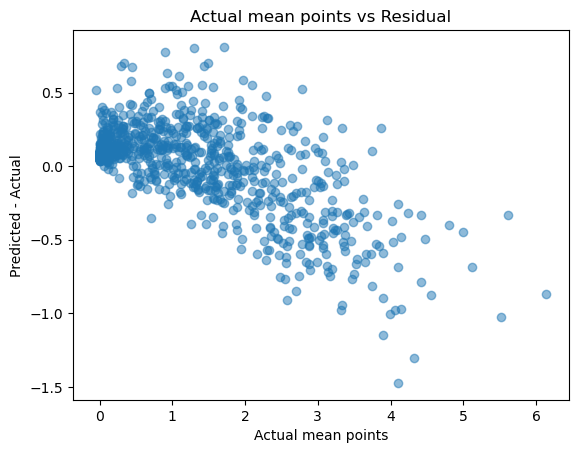

In [112]:
residual_plot(df_agg)

Strong positive correlation between how good a player is and how much the model underestimates them

In [122]:
model = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_l1, yhat_train_l1 = train_baseline_model(model, X_train, y_train)

yhat_test_l1 = test_baseline_model(model_l1, X_test, y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54094
[LightGBM] [Info] Number of data points in the train set: 196479, number of used features: 247
Training MAE: 1.0054073745444334
Training MSE: 5.141711439974345
Training Spearman: 0.6909806871208799
Test MAE: 0.8809339563654273
Test MSE: 4.37080620230239
Test Spearman: 0.7076578323250811


In [123]:
df_testing_summary_l1 = get_summary(test, X_test, yhat_test_l1)
df_testing_summary_l1.sort_values(by='yhat', ascending=False).head(50)

,web_name,player_game_key,fixture_key,player_id,total_points_recalculated,yhat
39186,M.Salah,2025_246_328,2025_246,118748,8.0,4.291862
58209,Haaland,2027_26_411,2027_26,223094,9.0,4.163294
18468,M.Salah,2025_275_328,2025_275,118748,15.0,4.134220
45899,M.Salah,2025_16_328,2025_16,118748,10.0,4.090610
27900,M.Salah,2025_105_328,2025_105,118748,14.0,4.086296
34301,M.Salah,2025_297_328,2025_297,118748,3.0,4.059691
25547,M.Salah,2025_305_328,2025_305,118748,2.0,4.049388
18753,M.Salah,2025_27_328,2025_27,118748,17.0,4.007414
30904,Haaland,2025_231_351,2025_231,223094,6.0,3.973129
23359,Haaland,2025_247_351,2025_247,223094,5.0,3.941393


In [124]:
df_agg_l1 = get_aggregates(df_testing_summary_l1)
df_agg_l1.sort_values('actual_mean', ascending=False).head(15)

,,pred_std,actual_std,pred_mean,actual_mean,n
player_id,web_name,,,,,
118748,M.Salah,0.969804,5.288236,2.571237,6.144737,76
223094,Haaland,0.728793,4.889297,2.600158,5.620253,79
141746,B.Fernandes,0.540064,4.976511,2.367483,5.518987,79
446008,Mbeumo,0.509924,4.421298,2.162869,5.126582,79
178186,Bowen,0.400501,3.669696,2.086827,5.000000,76
437730,Semenyo,0.489036,3.938879,2.385070,4.810127,79
222531,Gibbs-White,0.429748,4.177924,2.010440,4.556962,79
178301,Watkins,0.356276,4.168980,1.989056,4.468354,79
244850,Rogers,0.242620,3.771035,2.123527,4.417722,79


             actual_mean  residual
actual_mean     1.000000 -0.951971
residual       -0.951971  1.000000


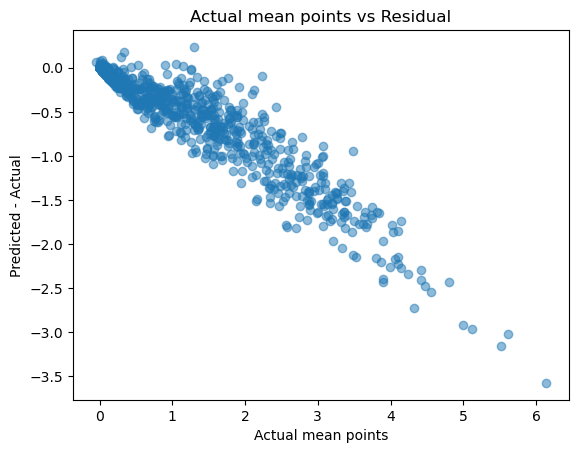

In [125]:
residual_plot(df_agg_l1)

L1 regression produces a more extreme correlation between player points average and underestimation.

In [156]:
query = """
    SELECT
        p.web_name,
        pg.player_game_key,
        pg.fixture_key,
        pg.player_id,
        pg.total_points_recalculated,
        avg(pg.total_points_recalculated) over last_5_games as yhat
    FROM dev_serving.fact_player_game pg
    JOIN dev_serving.dim_fixture f
    ON pg.fixture_key = f.fixture_key
    JOIN dev_serving.dim_player p
    ON pg.player_id = p.player_id
    WHERE f.season > 2024
    WINDOW last_5_games as (
        partition by pg.player_id
        order by kickoff_time
        rows between 5 preceding and 1 preceding
    )
"""

df_naive = query_database(query)
df_naive = df_naive.fillna(0)

In [148]:
mae = mean_absolute_error(df_naive['total_points_recalculated'], df_naive['yhat'])
mse = mean_squared_error(df_naive['total_points_recalculated'], df_naive['yhat'])
spearman = spearmanr(df_naive['total_points_recalculated'], df_naive['yhat']).correlation

print(f'Test MAE: {mae}')
print(f'Test MSE: {mse}')
print(f'Test Spearman: {spearman}')

Test MAE: 1.0627023862054479
Test MSE: 4.475427622770552
Test Spearman: 0.686718984486755


             actual_mean  residual
actual_mean     1.000000 -0.153823
residual       -0.153823  1.000000


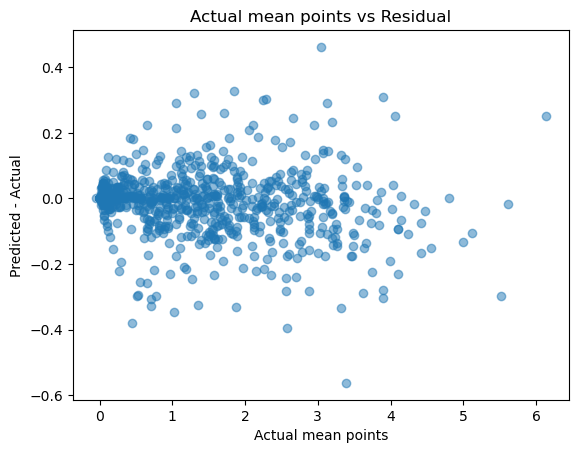

In [155]:
df_agg_naive = get_aggregates(df_naive)
residual_plot(df_agg_naive)

Underprediction of elite players does not reflect in a naive rolling 5 game average prediction

In [158]:
query = """
    SELECT
        p.web_name,
        pg.player_game_key,
        pg.fixture_key,
        pg.player_id,
        pg.total_points_recalculated,
        avg(pg.total_points_recalculated) over last_5_games as avg_points_last_5_games
    FROM dev_serving.fact_player_game pg
    JOIN dev_serving.dim_fixture f
    ON pg.fixture_key = f.fixture_key
    JOIN dev_serving.dim_player p
    ON pg.player_id = p.player_id
    WINDOW last_5_games as (
        partition by pg.player_id
        order by kickoff_time
        rows between 5 preceding and 1 preceding
    )
"""

df_aug = query_database(query)
df_aug = df_aug.fillna(0)

In [160]:
df_aug = pd.merge(df_all, df_aug[['player_game_key', 'avg_points_last_5_games']])

train_aug = df_aug[df_aug['season'] < 2025]
test_aug = df_aug[df_aug['season'] >= 2025]

In [161]:
df_training, categories = preprocess_data(train_aug, fit=True)
df_test, _ = preprocess_data(test_aug, fit_categories=categories, fit=False)

X_train = df_training.drop(columns=['points'])
y_train = df_training['points']

X_test = df_test.drop(columns=['points'])
y_test = df_test['points']

In [163]:
lgbm = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_aug, yhat_train = train_baseline_model(lgbm, X_train, y_train)
yhat_aug = test_baseline_model(model_aug, X_test, y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.081657 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54203
[LightGBM] [Info] Number of data points in the train set: 196479, number of used features: 248
[LightGBM] [Info] Start training from score 1.325831
Training MAE: 1.045534386199023
Training MSE: 3.519173591261245
Training Spearman: 0.709027054571456
Test MAE: 1.016593087546101
Test MSE: 3.7980793947485116
Test Spearman: 0.6965306903795354


In [166]:
aug_summary = get_summary(test_aug, X_test, yhat_test)
df_agg_aug = get_aggregates(aug_summary)
df_agg_aug.sort_values('actual_mean', ascending=False).head(15)

,,pred_std,actual_std,pred_mean,actual_mean,n
player_id,web_name,,,,,
118748,M.Salah,1.346613,5.288236,5.275802,6.144737,76
223094,Haaland,1.369817,4.889297,5.285536,5.620253,79
141746,B.Fernandes,1.045549,4.976511,4.494723,5.518987,79
446008,Mbeumo,0.869711,4.421298,4.440569,5.126582,79
178186,Bowen,0.894376,3.669696,4.554104,5.000000,76
437730,Semenyo,0.798218,3.938879,4.412233,4.810127,79
222531,Gibbs-White,0.745200,4.177924,3.679809,4.556962,79
178301,Watkins,1.024745,4.168980,3.971930,4.468354,79
244850,Rogers,0.823405,3.771035,3.631028,4.417722,79


             actual_mean  residual
actual_mean     1.000000 -0.614955
residual       -0.614955  1.000000


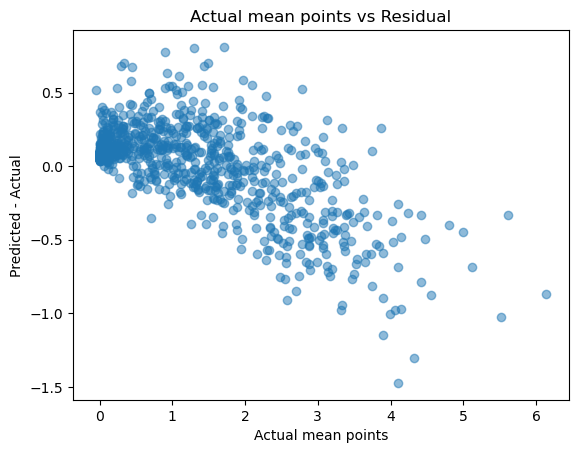

In [167]:
residual_plot(df_agg_aug)